In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
#eda

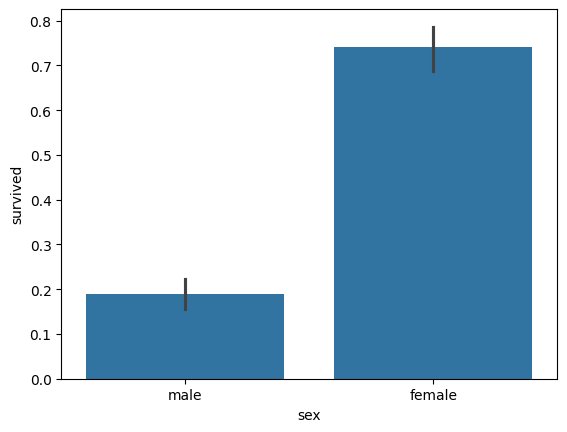

In [8]:
sns.barplot(x='sex', y='survived', data=df)
plt.show()

In [9]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [10]:
#Tahliyede kadınlara öncelik veriliyor.

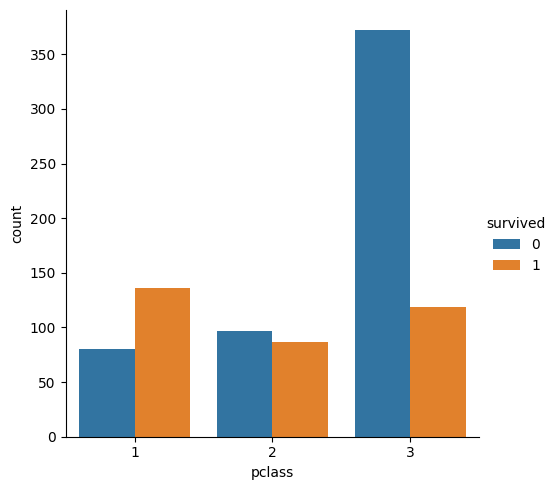

In [11]:
sns.catplot(x='pclass', hue='survived', kind='count', data=df)
plt.show()

In [12]:
# Sınıf içindeki hayatta kalan/hayatta kalmayanların yüzdesine bakarsak
# Açıkça görülüyor ki, 1. ve 2. sınıflar 3. sınıftan daha şanslı


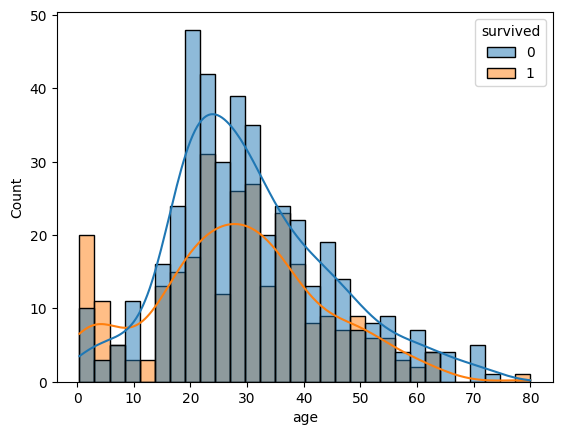

In [13]:
sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True)
plt.show()

In [14]:

# Tahliye sırasında çocuklara öncelik veriliyor gibi görünüyor

In [15]:
df["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

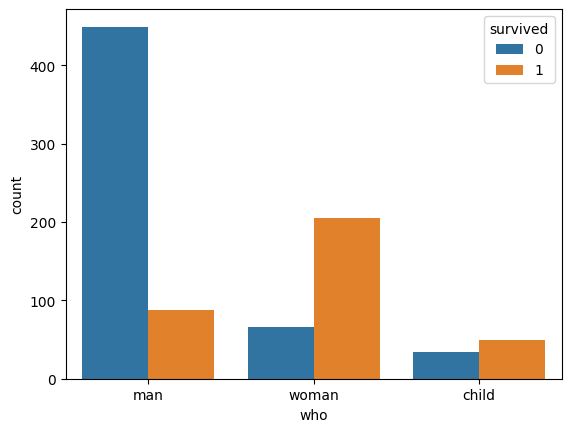

In [16]:
sns.countplot(x='who', hue='survived', data=df)
plt.show()

In [17]:
# Burada da aynı şeyi görüyoruz, kadınlara ve çocuklara öncelik veriliyor.

In [18]:
#feature engineering

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
# Kullanmayacağımız sütunları siliyoruz
df = df.drop(['deck', 'embark_town', 'alive'], axis=1)

In [22]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [23]:

# Eksik değerleri medyan veya mod ile değiştiriyoruz
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [24]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


In [26]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [27]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [28]:
df['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [29]:
df['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [30]:
# Mantıksal veri tiplerini 0 ve 1'lere dönüştürelim
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [31]:
X = df.drop('survived', axis=1)
y = df['survived']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['sex', 'class', 'who','embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [35]:
encoded_cols = preprocessor.get_feature_names_out()

In [36]:
# X_train ve X_test pandas veri çerçevelerini oluşturuyoruz, böylece daha sonra eğitim dışında başka bir şeye ihtiyacımız olursa bunları kullanabiliriz.
X_train = pd.DataFrame(X_train, columns = encoded_cols)
X_test = pd.DataFrame(X_test, columns = encoded_cols)
X_train.head()

,cat__sex_male,cat__class_Second,cat__class_Third,cat__who_man,cat__who_woman,cat__embarked_Q,cat__embarked_S,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,27.0,0.0,0.0,7.8958,1.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,17.0,0.0,0.0,10.5000,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,28.0,0.0,0.0,0.0000,1.0,1.0
3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,26.0,0.0,0.0,8.0500,1.0,1.0
4,1.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,43.0,0.0,0.0,8.0500,1.0,1.0


In [37]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.3 MB/s  0:00:01 eta 0:00:01


In [38]:
import lightgbm as lgb

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
clf = lgb.LGBMClassifier(verbosity=-1)
clf.fit(X_train, y_train)

LGBMClassifier(verbosity=-1)

In [41]:
y_pred = clf.predict(X_test)

In [42]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       128
           1       0.75      0.76      0.75        95

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.79      0.79      0.79       223

[[104  24]
 [ 23  72]]


In [43]:
importances = clf.feature_importances_

feature_names = X_train.columns
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importance)

                  Feature  Importance
11        remainder__fare        1132
8          remainder__age         865
6         cat__embarked_S          81
10       remainder__parch          77
9        remainder__sibsp          65
0           cat__sex_male          60
2        cat__class_Third          51
1       cat__class_Second          41
13       remainder__alone          41
4          cat__who_woman          36
5         cat__embarked_Q          35
3            cat__who_man          19
7       remainder__pclass          10
12  remainder__adult_male           0


In [44]:
#hyperparameter tuning

In [45]:
from sklearn.model_selection import RandomizedSearchCV

In [46]:
lgb_model = lgb.LGBMClassifier(verbosity=-1)


In [47]:

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


In [48]:
random_search = RandomizedSearchCV(estimator=lgb_model, param_distributions=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1, )

In [49]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, -1],
                                        'min_child_samples': [5, 10, 20],
                                        'n_estimators': [100, 300, 500, 1000],
                                        'num_leaves': [15, 31, 63, 127],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='accuracy', verbose=1)

In [50]:
random_search.best_params_

{'subsample': 0.8,
 'num_leaves': 31,
 'n_estimators': 300,
 'min_child_samples': 5,
 'max_depth': -1,
 'learning_rate': 0.01,
 'colsample_bytree': 0.6}

In [51]:
y_pred = random_search.predict(X_test)

In [52]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       128
           1       0.81      0.82      0.82        95

    accuracy                           0.84       223
   macro avg       0.84      0.84      0.84       223
weighted avg       0.84      0.84      0.84       223

[[110  18]
 [ 17  78]]


In [53]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [54]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       129
           1       0.73      0.74      0.74        94

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223

[[103  26]
 [ 24  70]]


In [55]:
params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [56]:
# Randomized search
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(n_estimators=100),
    param_distributions=params,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=100, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.8, 1, 0.3,
                                                             0.4],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy', verbose=1)

In [57]:
y_pred = random_search.predict(X_test)

In [58]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       144
           1       0.72      0.87      0.79        79

    accuracy                           0.83       223
   macro avg       0.82      0.84      0.83       223
weighted avg       0.85      0.83      0.84       223

[[117  27]
 [ 10  69]]
